In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

import numpy as np
import matplotlib.pyplot as plt
from src.MyDataset import MyDataset


import time

c:\Users\user\anaconda3\envs\imageClassification\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
#  CONSTANTS
batch_size = 16
num_workers = 4

epochs = 25
mini_batches_len = 10

In [ ]:
train_set = MyDataset("./labels/train_labels.csv", "./imgs/dataset/train_imgs", transform=transform)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers)

print(f"Train set length: {len(train_set)}")

Train set length: 2499


In [5]:
classes = ("apple", "banana", "orange", "pineapple", "watermelon")

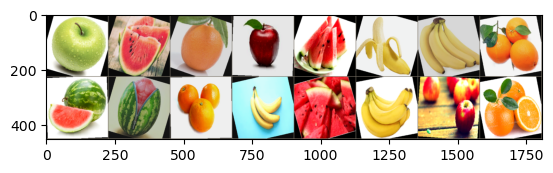

apple watermelon orange apple watermelon banana banana orange watermelon watermelon orange banana watermelon banana apple orange


In [6]:

def imshow(img):
    mean = torch.tensor([0.485,0.456,0.406])
    std = torch.tensor([0.229,0.224,0.225])

    img = img.clone()

    for i in range(3):
        img[i] = img[i] * std[i] + mean[i]

    npimg = img.numpy()
    plt.imshow(np.transpose(npimg,(1,2,0)))
    plt.show()

dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))

print(' '.join('%s' % classes[labels[j]] for j in range(batch_size)))

In [7]:
net = models.resnet18(weights="DEFAULT")

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:
net.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(512,5)
)

for param in net.parameters():
    param.requires_grad = False

for param in net.layer4.parameters():
    param.requires_grad = True

for param in net.fc.parameters():
    param.requires_grad = True

In [9]:
criterion = nn.CrossEntropyLoss(
    label_smoothing=0.0
)
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, net.parameters()),
    lr=0.0001,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)


In [10]:
trainable = 0
total = 0

for name, param in net.named_parameters():
    total += param.numel()

    if param.requires_grad:
        trainable += param.numel()
        print(name)

print("----------------")
print("Trainable:", trainable)
print("Total:", total)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.1.weight
fc.1.bias
----------------
Trainable: 8396293
Total: 11179077


In [11]:
start = time.time()

lossArr = []

net.train()

for epoch in range(epochs):
    running_loss = 0.0
    epoch_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        inputs, labels = data
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        epoch_loss += loss.item()

        if i % mini_batches_len == mini_batches_len-1:
            print(
                f'[{epoch+1}, {i+1}] loss: {running_loss/mini_batches_len}'
            )
            lossArr.append(running_loss/mini_batches_len)
            running_loss = 0.0

    scheduler.step(epoch_loss / len(train_loader))

    print(
        f"Epoch {epoch+1} average loss: {epoch_loss/len(train_loader)}"
    )

end = time.time()

print(f'Finished Training!, Time: {end-start} sec...')

[1, 10] loss: 1.4284559845924378
[1, 20] loss: 0.8183608889579773
[1, 30] loss: 0.55722696185112
[1, 40] loss: 0.3694535091519356
[1, 50] loss: 0.4856938436627388
[1, 60] loss: 0.36925381124019624
[1, 70] loss: 0.271989144384861
[1, 80] loss: 0.2736295834183693
[1, 90] loss: 0.3366956956684589
[1, 100] loss: 0.26951007544994354
[1, 110] loss: 0.29741268903017043
[1, 120] loss: 0.21635536551475526
[1, 130] loss: 0.16379617527127266
[1, 140] loss: 0.32855405025184153
[1, 150] loss: 0.16951564475893974
Epoch 1 average loss: 0.4175861449615591
[2, 10] loss: 0.19676569383591413
[2, 20] loss: 0.18615552522242068
[2, 30] loss: 0.2137741507962346
[2, 40] loss: 0.15604609809815884
[2, 50] loss: 0.11573046296834946
[2, 60] loss: 0.20484762489795685
[2, 70] loss: 0.1368204084224999
[2, 80] loss: 0.2491311153396964
[2, 90] loss: 0.11361536737531423
[2, 100] loss: 0.09896526001393795
[2, 110] loss: 0.17179676070809363
[2, 120] loss: 0.15159661090001464
[2, 130] loss: 0.0942262765020132
[2, 140] los

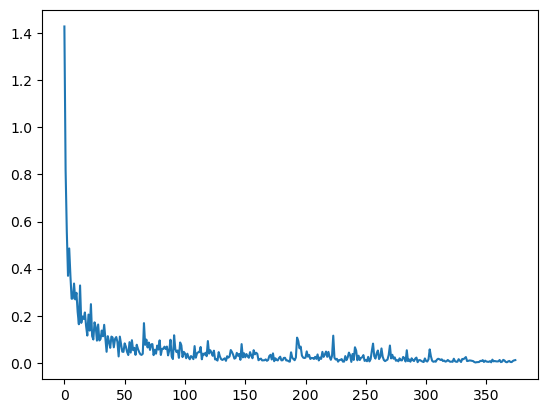

In [12]:
plt.plot(lossArr)

In [13]:
PATH = './models/resnet182layersUnFreezed25epochNoLabelSmoothing.pth'
torch.save(net.state_dict(), PATH)